# **🚜 Predicting the Sale Price of Bulldozers using Machine Learning**

In this notebook, we're going to go through an example of machine learning project with the goal of predicting the sale price of bulldozers.

- **Inputs**: Bulldozer characteristics such as make year, base model, model series, state of sale (e.g. which US state was it sold in), drive system and more.
- **Outputs**: Bulldozer sale price (in USD).

---

Since we're trying to predict a number, this kind of problem is known as a **regression problem**.


And since we're going to predicting results with a time component (predicting future sales based on past sales), this is also known as a **time series** or **forecasting problem**.


- The [Data](https://www.dropbox.com/scl/fi/pjrulzwpa2osmtcl34j5c/dog-breed-identification.zip?rlkey=illavzwa19vysrolwpgqov86a&e=1&dl=0) is taken from [Kaggle Bluebook for Buldozers competition](https://www.kaggle.com/competitions/bluebook-for-bulldozers/overview)

---

# **Overview**

Since we already have a dataset, we'll approach the problem with the following machine learning modelling framework.

<center>

![6 Step Machine Learning Modelling Framework](./assets/images/6%20Step%20Machine%20Learning%20Modelling%20Framework.png)

</center>

---

<center>

> 6 Step Machine Learning Modelling Framework

</center>


**Thought Process:**

![6 Step ml plan](./assets/images/6-step-ml-framework.png)

## **1. Problem Defination:**

> How well we can predict the future sales price of a bulldozer, given it's characteristic and previous examples of how much similar bulldozers have been sold for? 

## **2. Data**

The data is downloaded from Kaggle [Bluebook for Bulldozers Compitition](https://www.kaggle.com/competitions/bluebook-for-bulldozers/overview).


**There are 3 main datasets:**

- **Train.csv** - Historical bulldozer sales examples up to 2011 (close to 400,000 examples with 50+ different attributes, including SalePrice which is the target variable).
  
- **Valid.csv** - Historical bulldozer sales examples from January 1 2012 to April 30 2012 (close to 12,000 examples with the same attributes as Train.csv).
  
- **Test.csv** - Historical bulldozer sales examples from May 1 2012 to November 2012 (close to 12,000 examples but missing the SalePrice attribute, as this is what we'll be trying to predict).

## **3. Evaluation**

The evaluation metric for this competition is the **`RMSLE`** (**root mean squared log error**) between the actual and predicted auction prices.

For more evaluation of this project check: [Here](www.kaggle.com/competitions/bluebook-for-bulldozers/overview/evaluation)


> **Note:** The goal for most regression evaluation metrics is to minimize the error.
>For example, our goal for this project is to build a machine learning model which minimises **`RMSLE`**.

## **4. Features**

Kaggle provides a data dictionary for all of the features of the dataset. You can view this data:
- [URL](https://www.kaggle.com/competitions/bluebook-for-bulldozers/data)
- [Locally for me](./dataset/Data%20Dictionary.xlsx)

## **Importing the data and preparing it for modelling**

In [35]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

In [36]:
# Import training and validation sets

df = pd.read_csv("./dataset/TrainAndValid.csv",
                 low_memory=False)

# Use low_memory=False so pandas
# reads the CSV more reliably and avoids
# guessing column types in chunks.

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   str    
 9   saledate                  412698 non-null  str    
 10  fiModelDesc               412698 non-null  str    
 11  fiBaseModel               412698 non-null  str    
 12  fiSecondaryDesc           271971 non-null  str    
 13  fiModelSeries             58667 non-null   str    
 14 

In [38]:
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

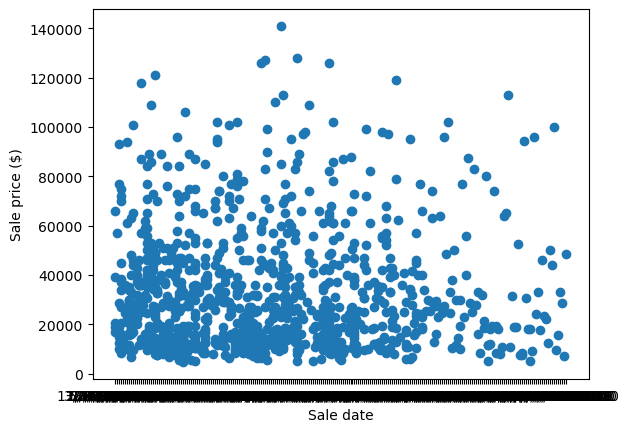

In [39]:
fig, ax = plt.subplots()
ax.scatter(df["saledate"][:1000], df["SalePrice"][:1000])
ax.set_xlabel("Sale date")
ax.set_ylabel("Sale price ($)");

In [40]:
df.saledate[:1000]

0      11/16/2006 0:00
1       3/26/2004 0:00
2       2/26/2004 0:00
3       5/19/2011 0:00
4       7/23/2009 0:00
            ...       
995     7/16/2009 0:00
996     6/14/2007 0:00
997     9/22/2005 0:00
998     7/28/2005 0:00
999     6/16/2011 0:00
Name: saledate, Length: 1000, dtype: str

In [ ]:
df["saledate"].dtypes

<StringDtype(storage='python', na_value=nan)>

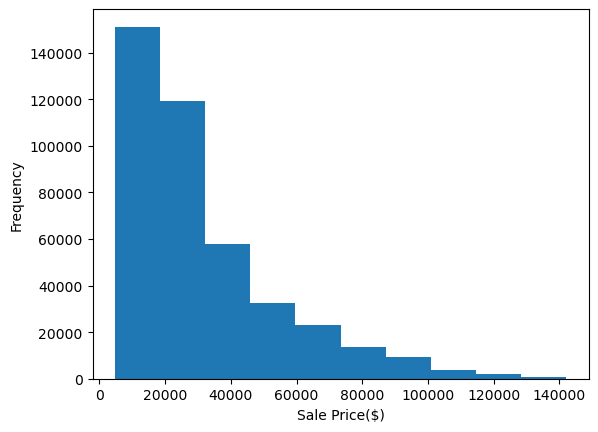

In [42]:
df.SalePrice.plot.hist()
plt.xlabel("Sale Price($)");

### **Parsing Dates**

When we are working with **time series data**, we want to enrich the time and date component as much as possible.

We can do that by telling the pandas which of our columns has dates in it using the **`parse_dates`** parameter.

In [43]:
# Import the data again but this tiime parse dates
df = pd.read_csv("./dataset/TrainAndValid.csv",
                 low_memory=False,
                 parse_dates=["saledate"])

`parse_dates=["saledate"]` tells pandas:

> "When you load this column, don't treat it as text — convert it into a proper DateTime object automatically."

- Without it → `saledate` is dtype `object` (string)
With it → `saledate` is dtype `datetime64` (real date)

In [ ]:
df.saledate.dtype

# dtype('<M8[us]') means the column is a NumPy
# datetime type (date + time), stored with
# microsecond (us) precision

dtype('<M8[us]')

In [45]:
df.saledate[:1000]

0     2006-11-16
1     2004-03-26
2     2004-02-26
3     2011-05-19
4     2009-07-23
         ...    
995   2009-07-16
996   2007-06-14
997   2005-09-22
998   2005-07-28
999   2011-06-16
Name: saledate, Length: 1000, dtype: datetime64[us]

In [48]:
np.dtype('<M8[us]') == np.dtype('<datetime64[us]')

True

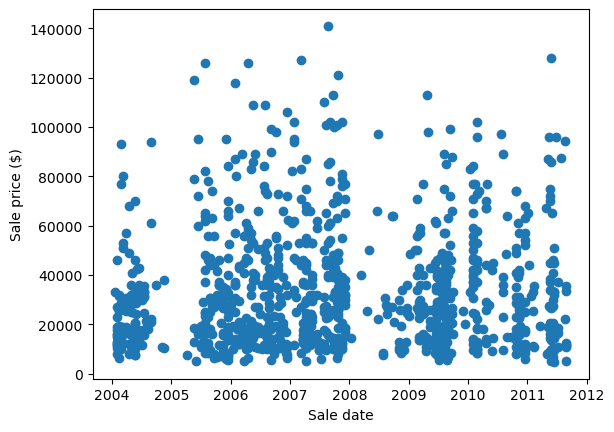

In [51]:
fig, ax = plt.subplots()
ax.scatter(df['saledate'][:1000], df['SalePrice'][:1000])
ax.set_xlabel("Sale date")
ax.set_ylabel("Sale price ($)");

In [52]:
df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,2006-11-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,2004-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2004-02-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,2011-05-19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,2009-07-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
